## BASIC WAVETABLE SYNTHESIS

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.io import wavfile 
from scipy.signal import butter, lfilter_zi, lfilter
from scipy.signal import convolve
from IPython.display import Audio

In [2]:
sample_rate = 44100
frequency = 440.0
duration = 2.0
loss = 0.996
t = np.linspace(0, 1, num=100)

In [3]:
total_samples = int(sample_rate * duration)
tube_len = int(sample_rate / frequency / 2 ) 

open_bc = -0.997
closed_bc = 0.999

left_delay_line = np.zeros(tube_len) #Sound wave traveling from closed to open, incident 
right_delay_line = np.zeros(tube_len) #Sound wave traveling from open to closed, reflected
wt_syn_output=np.zeros(total_samples) #At time zero, no output

for i in range(total_samples):
    wt_syn_output[i] = right_delay_line[-1] + left_delay_line[-1] #output is measured at open, right, end
    new_left_entry = right_delay_line[-1] * open_bc #right wave travels to open end and is reflected
    new_right_entry = left_delay_line[0] * closed_bc #left wave travels to closed end and is bounced

    if i < tube_len:
        new_right_entry += np.random.uniform(-1.0,1.0) #excitation

    left_delay_line = np.append(left_delay_line[1:], new_left_entry) # new entry at right end
    right_delay_line = np.append(new_right_entry, right_delay_line[:-1]) # new entry at left end

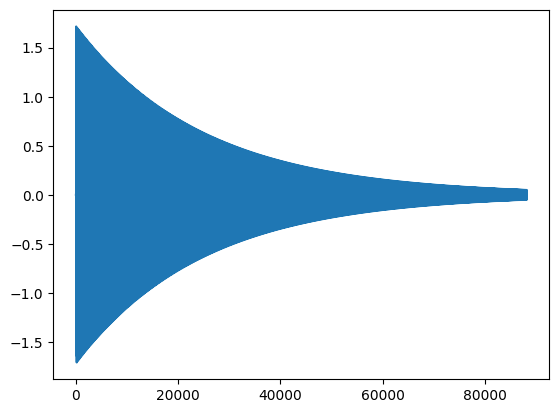

In [4]:
plt.plot(wt_syn_output)

(array([3.01524687e-12, 3.01534992e-12, 3.01565921e-12, ...,
        2.79161180e-10, 2.79127346e-10, 2.79116068e-10], shape=(44101,)),
 array([0.00000e+00, 5.00000e-01, 1.00000e+00, ..., 2.20490e+04,
        2.20495e+04, 2.20500e+04], shape=(44101,)),
 <matplotlib.lines.Line2D at 0x194af406d50>)

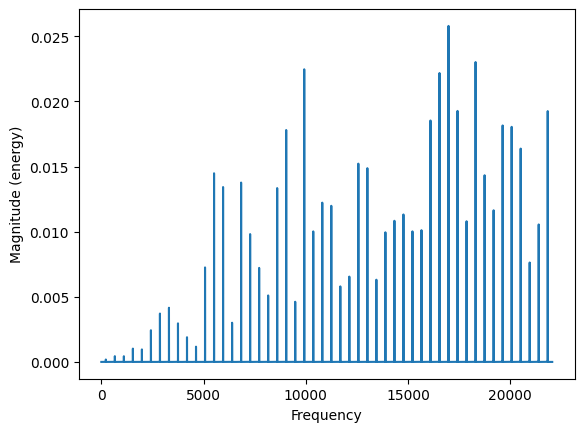

In [5]:
plt.magnitude_spectrum(wt_syn_output, Fs=sample_rate)

In [6]:
Audio(wt_syn_output, rate = sample_rate)

Using Loss Filter

In [7]:
total_samples = int(sample_rate * duration)
tube_len = int(sample_rate / frequency / 2 ) 

open_bc = -0.997
closed_bc = 0.999

left_delay_line = np.zeros(tube_len) #Sound wave traveling from closed to open, incident 
right_delay_line = np.zeros(tube_len) #Sound wave traveling from open to closed, reflected
wt_syn_output=np.zeros(total_samples) #At time zero, no output

#Low Filter Initialization
cutoff_hz = 6000
b, a = butter(1, cutoff_hz / (sample_rate / 2), btype='low')
# initialise state to zero (filter starts with no history)
zi = lfilter_zi(b, a) * 0.0
zi_open   = lfilter_zi(b, a) * 0.0
zi_closed = lfilter_zi(b, a) * 0.0

for i in range(total_samples):
    wt_syn_output[i] = right_delay_line[-1] + left_delay_line[-1] #output is measured at open, right, end
    #new_left_entry = right_delay_line[-1] * open_bc #right wave travels to open end and is reflected

    #using loss filter

    sample_out, zi_open = lfilter(b, a, [right_delay_line[-1]], zi=zi_open)
    new_left_entry = sample_out[0] * -1.0
    
    new_right_entry = left_delay_line[0] * closed_bc #left wave travels to closed end and is bounced

    if i < tube_len:
        new_right_entry += np.random.uniform(-1.0,1.0) #excitation

    left_delay_line = np.append(left_delay_line[1:], new_left_entry) # new entry at right end
    right_delay_line = np.append(new_right_entry, right_delay_line[:-1]) # new entry at left end

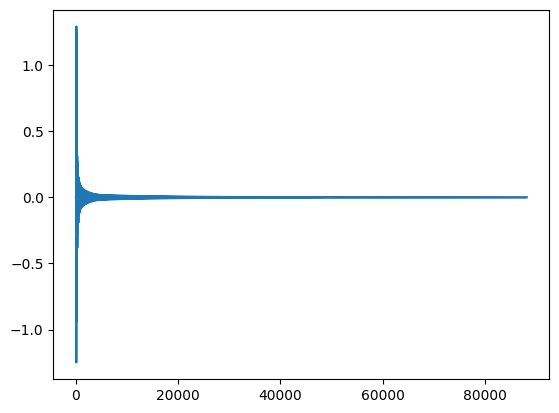

In [8]:
plt.plot(wt_syn_output)

(array([7.99833023e-12, 7.99860433e-12, 7.99942663e-12, ...,
        2.05040834e-10, 2.05037485e-10, 2.05036369e-10], shape=(44101,)),
 array([0.00000e+00, 5.00000e-01, 1.00000e+00, ..., 2.20490e+04,
        2.20495e+04, 2.20500e+04], shape=(44101,)),
 <matplotlib.lines.Line2D at 0x194b0632710>)

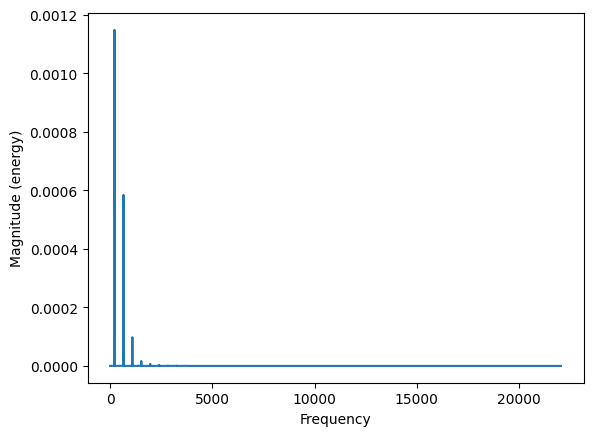

In [9]:
plt.magnitude_spectrum(wt_syn_output, Fs=sample_rate)

In [10]:
Audio(wt_syn_output, rate = sample_rate)

## Shape: Cone vs. Cylinder

In [11]:
#Cylinder 
total_samples = int(sample_rate * duration)
tube_len = int(sample_rate / frequency / 2 ) 

open_bc = -0.997
closed_bc = 0.999

left_delay_line = np.zeros(tube_len) #Sound wave traveling from closed to open, incident 
right_delay_line = np.zeros(tube_len) #Sound wave traveling from open to closed, reflected
cylinder_output =np.zeros(total_samples) #At time zero, no output

#Low Filter Initialization
cutoff_hz = 6000
b, a = butter(1, cutoff_hz / (sample_rate / 2), btype='low')
# initialise state to zero (filter starts with no history)
zi = lfilter_zi(b, a) * 0.0
zi_open   = lfilter_zi(b, a) * 0.0
zi_closed = lfilter_zi(b, a) * 0.0

for i in range(total_samples):
    cylinder_output[i] = right_delay_line[-1] + left_delay_line[-1] #output is measured at open, right, end
    #new_left_entry = right_delay_line[-1] * open_bc #right wave travels to open end and is reflected

    #using loss filter

    sample_out, zi_open = lfilter(b, a, [right_delay_line[-1]], zi=zi_open)
    new_left_entry = sample_out[0] * -1.0
    
    new_right_entry = left_delay_line[0] * closed_bc #left wave travels to closed end and is bounced

    if i < tube_len:
        new_right_entry += np.random.uniform(-1.0,1.0) #excitation

    left_delay_line = np.append(left_delay_line[1:], new_left_entry) # new entry at right end
    right_delay_line = np.append(new_right_entry, right_delay_line[:-1]) # new entry at left end

(array([1.30017609e-13, 1.30071654e-13, 1.30233676e-13, ...,
        4.74885812e-10, 4.74886564e-10, 4.74886814e-10], shape=(44101,)),
 array([0.00000e+00, 5.00000e-01, 1.00000e+00, ..., 2.20490e+04,
        2.20495e+04, 2.20500e+04], shape=(44101,)),
 <matplotlib.lines.Line2D at 0x194ad2687d0>)

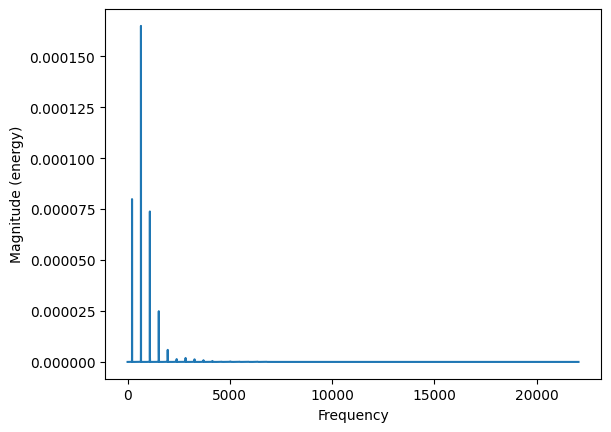

In [12]:
plt.magnitude_spectrum(cylinder_output, Fs = sample_rate)

r range: -0.4382 to -0.1918
sec_len: 10, total_delay: 50


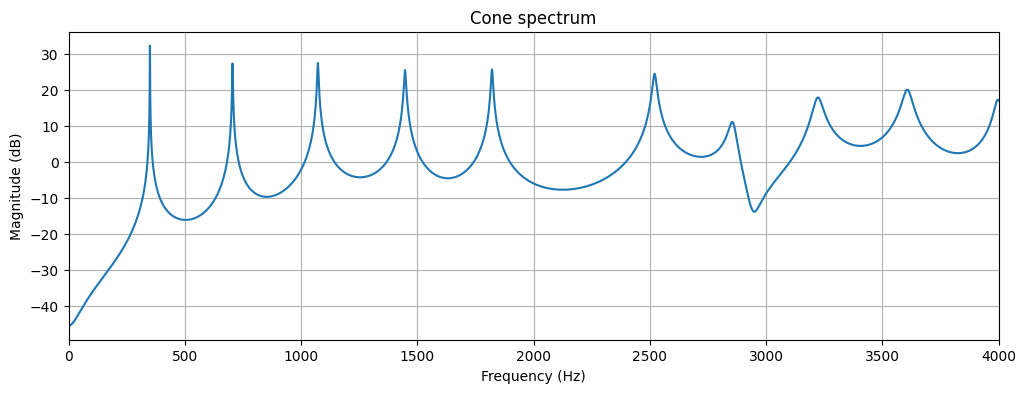

In [24]:
# Cone construction
N_sections = 5
radii = np.linspace(0.005, 0.02, N_sections + 1)
#radii = np.linspace(0.01, 0.01, N_sections + 1)
areas = np.pi * radii ** 2

# Reflection coefficient at each interior junction
r = np.zeros(N_sections - 1)
for k in range(N_sections - 1):
    r[k] = (areas[k] - areas[k+1]) / (areas[k] + areas[k+1])

# Delay lines
total_delay = int(sample_rate / frequency / 2)
sec_len     = max(1, total_delay // N_sections)
right = [np.zeros(sec_len) for _ in range(N_sections)]
left  = [np.zeros(sec_len) for _ in range(N_sections)]

# Loss filter
b, a      = butter(1, 6000 / (sample_rate / 2), btype='low')
zi_open   = lfilter_zi(b, a) * 0.0
zi_closed = lfilter_zi(b, a) * 0.0

total_samples  = int(duration * sample_rate)
output         = np.zeros(total_samples)
excitation_len = total_delay

for i in range(total_samples):
    # Read output at open (right) end of last section
    output[i] = right[-1][-1] + left[-1][-1]

    if np.isnan(output[i]) or np.abs(output[i]) > 1e6:
        print(f"Blew up at sample {i} of {total_samples}")
        break

    # Open end boundary: loss filter + sign inversion
    s, zi_open    = lfilter(b, a, [right[-1][-1]], zi=zi_open)
    new_left_last = s[0] * -1.0

    # Closed end boundary: loss filter + reflection at left end of first section
    s, zi_closed    = lfilter(b, a, [left[0][0]], zi=zi_closed)
    new_right_first = s[0] * 0.999

    # Excitation: noise into the closed end
    if i < excitation_len:
        new_right_first += np.random.uniform(-1.0, 1.0)

    # Interior junction scattering
    new_right = [None] * N_sections
    new_left  = [None] * N_sections

    for k in range(N_sections - 1):
        p_right = right[k][-1]
        p_left  = left[k+1][0]
        rk      = r[k]
    
        new_right[k+1] = (1 + rk) * p_right  -  rk * p_left
        new_left[k]    =  rk      * p_right  + (1 - rk) * p_left

    # Boundary conditions fill in the endpoints
    new_right[0]           = new_right_first
    new_left[N_sections-1] = new_left_last

    # Advance all delay lines
    for k in range(N_sections):
        right[k] = np.append(new_right[k], right[k][:-1])
        left[k]  = np.append(left[k][1:],  new_left[k])

print(f"r range: {r.min():.4f} to {r.max():.4f}")
print(f"sec_len: {sec_len}, total_delay: {total_delay}")

output /= np.max(np.abs(output) + 1e-9)
N   = len(output)
mag = np.abs(np.fft.rfft(output))
f   = np.fft.rfftfreq(N, d=1/sample_rate)

mag_db = 20 * np.log10(mag + 1e-10)
mag_db[mag_db < -60] = np.nan

plt.figure(figsize=(12, 4))
plt.plot(f, mag_db)
plt.xlim(0, 4000)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.title('Cone spectrum')
plt.grid(True)
plt.show()
Audio(output, rate=sample_rate)

## REED EXCITATION

In [30]:
SR = 44100

In [26]:
class DelayLine:
    """Fractional-delay ring buffer (linear interpolation).
 
    Integer-only delay quantises pitch to a grid far coarser than the ear's JND,
    so notes come out audibly flat/sharp. The fractional part is recovered by
    linearly interpolating between the two integer taps straddling the delay.
    Linear interp also adds a gentle high-frequency roll-off, which is
    conveniently *stabilising* for the feedback loop.
    """
    def __init__(self, delay, headroom=4):
        self.int_d = int(np.floor(delay))
        self.frac  = delay - self.int_d          # sub-sample remainder
        self.size  = self.int_d + headroom
        self.buf   = np.zeros(self.size)
        self.w     = 0
    def tick(self, x):
        self.buf[self.w] = x
        i0 = (self.w - self.int_d)     % self.size
        i1 = (self.w - self.int_d - 1) % self.size
        out = self.buf[i0] * (1.0 - self.frac) + self.buf[i1] * self.frac
        self.w = (self.w + 1) % self.size
        return out

In [27]:
class OnePoleLoss:
    """Frequency-dependent loss = a low-pass filter, not a scalar (M2).
 
    Per-sample form of the Butterworth loss from M2: y[n] = (1-a)x[n] + a*y[n-1].
    Larger `a` -> lower cutoff -> more high-frequency loss per round trip -> warmer,
    less buzzy tone. This is what strips a little top end each reflection.
    """
    def __init__(self, a=0.2):
        self.a = a; self.y = 0.0
    def tick(self, x):
        self.y = (1.0 - self.a) * x + self.a * self.y
        return self.y

In [28]:
class DCBlock:
    """One-pole high-pass at a few Hz. Nonlinear sources accumulate a DC offset
    that wastes headroom and thumps speakers; strip it on the output (guide 6.4)."""
    def __init__(self, r=0.995):
        self.r = r; self.x1 = 0.0; self.y1 = 0.0
    def tick(self, x):
        y = x - self.x1 + self.r * self.y1
        self.x1 = x; self.y1 = y
        return y

 The coupled loop

 Single delay line = the full round trip down the bore and back. The loop carries
 one net sign inversion per round trip (open end −1, reed ≈ +1 near closure), which
 doubles the period → **closed–open behaviour → odd harmonics** and pitch
 `f0 = SR / (2·D)`. So `D = SR/(2·f0)`.

 The reed is a **pressure-controlled valve**. The pressure difference across it,
 `Δp = p_bore − p_mouth`, sets a reflection coefficient: near zero Δp the reed is
 open (little reflection); as Δp drives the reed toward the mouthpiece rails it
 **snaps shut** and the end becomes rigid (r → +1). That hard closure — the
 `clip` — is the whole nonlinearity; it's what manufactures the odd harmonics that
 reinforce the cylinder's odd resonances. The smooth part of the curve barely
 matters.

In [31]:
def clarinet(f0=220.0, pm=0.5, dur=2.0, sr=SR,
             reflect_gain=-0.97,   # open-end reflection (−1 inversion) plus a little loss
             loss_a=0.2,           # M2 loss-filter strength
             reed_offset=0.7,      # reed reflection when Δp≈0 (reed open)
             reed_slope=-0.44,     # how fast the reed closes as Δp grows
             loop_comp=1.35,       # trims filter/interp group delay so pitch lands true
             excite_impulse=False):# True = disable reed, run the linear resonator gate
    """Return a normalised mono buffer. pm is the steady breath/embouchure control."""
    D = sr / (2.0 * f0) - loop_comp
    delay = DelayLine(D)
    loss  = OnePoleLoss(loss_a)
    dc    = DCBlock()
 
    n = int(dur * sr)
    out = np.zeros(n)
    returned = 0.0                                   # wave arriving back at the mouthpiece
 
    for i in range(n):
        # Open end: invert + frequency-dependent loss (this is the once-per-round-trip
        # boundary; folding it in here keeps the whole path in one delay line).
        bore = reflect_gain * loss.tick(returned)
 
        if excite_impulse:
            # Validation gate: reed removed -> mouthpiece is a rigid closed end (pass-through).
            # Pure linear closed-open resonator; its spectrum IS the tube's resonances.
            injected = bore + (1.0 if i == 0 else 0.0)
        else:
            # --- the reed nonlinearity ---
            pdiff = bore - pm                        # Δp across the reed
            r = reed_offset + reed_slope * pdiff     # reflection rises toward closure
            r = 1.0 if r > 1.0 else (-1.0 if r < -1.0 else r)   # HARD CLOSURE (the clip)
            injected = pm + r * pdiff                # wave sent back into the bore
 
        returned = delay.tick(injected)             # propagate the round trip
        out[i] = dc.tick(bore)                       # tap bore pressure, DC-blocked
 
    peak = np.max(np.abs(out))
    return out / peak if peak > 0 else out
 
#  Play it
 
# %%
y = clarinet(f0=220, pm=0.5, dur=3.0)
Audio(y, rate=SR)

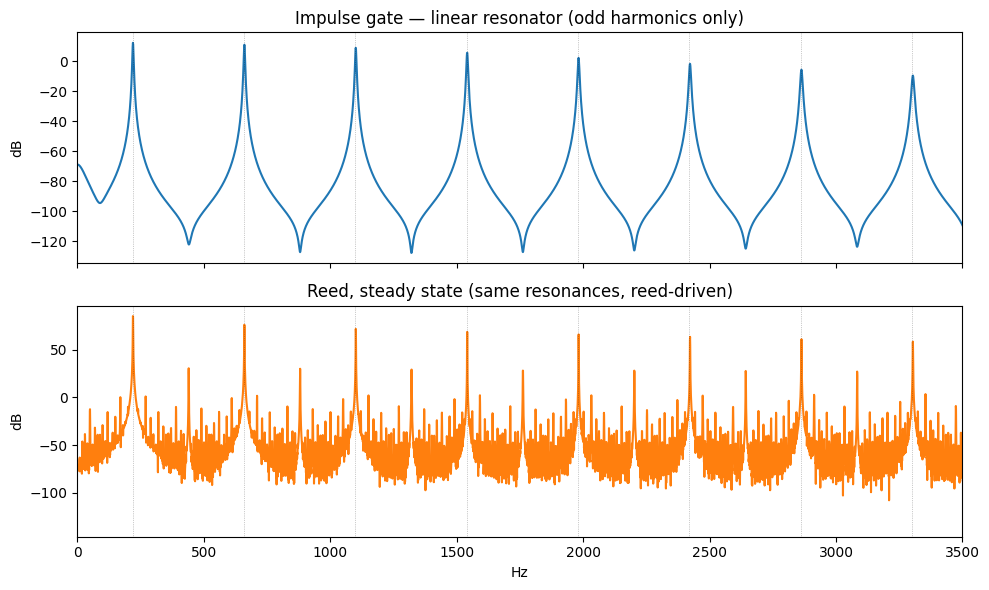

In [32]:
def spectrum_db(sig, sr=SR):
    w = np.hanning(len(sig))
    mag = np.abs(np.fft.rfft(sig * w))
    freqs = np.fft.rfftfreq(len(sig), 1/sr)
    return freqs, 20 * np.log10(mag + 1e-9)
 
imp = clarinet(f0=220, dur=1.0, excite_impulse=True)
f_i, db_i = spectrum_db(imp)
f_r, db_r = spectrum_db(clarinet(f0=220, pm=0.5, dur=2.0)[SR//4:])  # steady portion
 
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(f_i, db_i); ax[0].set_title("Impulse gate — linear resonator (odd harmonics only)")
ax[1].plot(f_r, db_r, color="C1"); ax[1].set_title("Reed, steady state (same resonances, reed-driven)")
for a in ax:
    for k in range(1, 16, 2):                       # mark expected odd harmonics
        a.axvline(220*k, color="k", ls=":", lw=0.5, alpha=0.4)
    a.set_xlim(0, 3500); a.set_ylabel("dB")
ax[1].set_xlabel("Hz")
plt.tight_layout(); plt.show()

 The lock-in experiment — sweep breath pressure

 Slowly raise `pm` and watch three regimes fall out of the loop (you never
programmed them):
* **below threshold** — losses win, nothing sustains → silence
* **lock-in range** — the loop entrains to the tube's lowest resonance; the
pitch is set by the tube and stays rock-solid as pm varies
* **choked** — pm holds the reed slapped shut → silence again

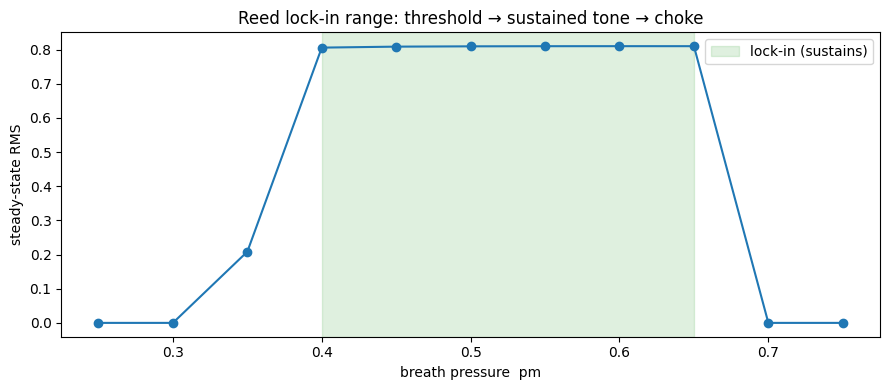

In [34]:
pressures = np.linspace(0.25, 0.75, 11)
rms = []
for pm in pressures:
    tail = clarinet(f0=220, pm=pm, dur=1.5)[-SR//10:]
    rms.append(np.sqrt(np.mean(tail**2)))
 
plt.figure(figsize=(9, 4))
plt.plot(pressures, rms, "o-")
plt.axvspan(0.4, 0.65, color="C2", alpha=0.15, label="lock-in (sustains)")
plt.xlabel("breath pressure  pm"); plt.ylabel("steady-state RMS")
plt.title("Reed lock-in range: threshold → sustained tone → choke")
plt.legend(); plt.tight_layout(); plt.show()

This uses one delay line (a plain cylinder). To hear a reed on a **cone**, swap
the single `DelayLine` for your M3 chain of sections + scattering junctions and
read `bore` from the mouthpiece end of that chain. The reed code is unchanged —
it only cares about the pressure it sees at the input. On a cone you'll get the
full harmonic series driven by the same reed: a saxophone body instead of a
clarinet.

## Radiation and the Bell

In [37]:
SR = 44100
C  = 343.0   # speed of sound, m/s

In [38]:
class DelayLine:
    """Fractional delay with separate read()/write() so a chain of sections can be
    updated in lock-step: read all outputs (delayed state), compute all junction
    scatterings, then write all inputs. This ordering is what prevents an
    instantaneous algebraic loop through the junctions."""
    def __init__(self, delay, headroom=4):
        self.int_d = int(np.floor(delay))
        self.frac  = delay - self.int_d
        self.size  = self.int_d + headroom
        self.buf   = np.zeros(self.size)
        self.w     = 0
    def read(self):
        i0 = (self.w - self.int_d) % self.size
        i1 = (self.w - self.int_d - 1) % self.size
        return self.buf[i0]*(1.0-self.frac) + self.buf[i1]*self.frac
    def write(self, x):
        self.buf[self.w] = x
        self.w = (self.w + 1) % self.size

In [39]:
class OnePole:
    """One-pole low-pass. Used as the radiation reflection filter."""
    def __init__(self, a): self.a = a; self.y = 0.0
    def tick(self, x):
        self.y = (1.0 - self.a) * x + self.a * self.y
        return self.y

In [40]:
class DCBlock:
    def __init__(self, r=0.995): self.r=r; self.x1=0.0; self.y1=0.0
    def tick(self, x):
        y = x - self.x1 + self.r*self.y1; self.x1 = x; self.y1 = y; return y

In [41]:
def cutoff_from_radius(radius_m):
    """Radiation cutoff from opening size (ka ~ 1). Bigger opening -> lower cutoff
    -> lower frequencies escape. This is the physical meaning of the bell."""
    return C / (2*np.pi*radius_m)

# The instrument

 The bell end is the whole point. The arriving right-going wave is split into:
 * `reflected = -R(arrived)` — a low-pass (`R`) with the open-end inversion. The
   lows come back with near-full strength and keep the oscillation going; the
  highs are stripped out of the reflection.
  * `radiated = arrived + reflected` — the complement, which is a HIGH-PASS. This
    is the audio you hear. At DC it's ~0 (lows don't escape); up high it -> the
   full wave (highs escape).

The radiation filter also adds group delay, which lengthens the loop — the digital
form of the **end correction** (the tube acts acoustically longer than it
 measures). That's why `loop_comp` has to grow when you lower the cutoff.

In [42]:
def wind(areas, f0=220.0, pm=0.5, dur=2.0, sr=SR,
         rad_cutoff_hz=2500.0,   # radiation cutoff = opening size (see cutoff_from_radius)
         loop_comp=1.1,          # end-correction trim; retune if you change the cutoff
         loss=0.995,             # broadband wall loss / stability margin
         reed_offset=0.7, reed_slope=-0.44,
         excite_impulse=False):
    """Return (radiated, internal): the sound that escapes, and the bore pressure
    inside near the mouthpiece. `areas` is the bore profile; uniform = cylinder."""
    areas = np.asarray(areas, float)
    N = len(areas)
    a_rad = float(np.exp(-2*np.pi*rad_cutoff_hz/sr))   # one-pole coeff from cutoff
 
    # closed-open cylinder: net inversion per round trip -> f0 = sr/(4*D_line)
    D_line = sr/(4.0*f0) - loop_comp
    D_sec  = D_line / N
    right = [DelayLine(D_sec) for _ in range(N)]
    left  = [DelayLine(D_sec) for _ in range(N)]
 
    # interior scattering-junction reflection coefficients (M3): r=(A_k - A_{k+1})/(...)
    rj = [(areas[k]-areas[k+1])/(areas[k]+areas[k+1]) for k in range(N-1)]
    Rfilter = OnePole(a_rad)
    dc_in, dc_out = DCBlock(), DCBlock()
 
    n = int(dur*sr)
    radiated_buf = np.zeros(n)
    internal_buf = np.zeros(n)
 
    for i in range(n):
        # read every delay-line output first (all delayed state)
        aR = [right[k].read() for k in range(N)]   # right-going, at each section's far end
        aL = [left[k].read()  for k in range(N)]   # left-going,  at each section's near end
 
        # --- mouthpiece: the reed (M4), unchanged. The inversion now lives at the bell. ---
        bore = aL[0]
        if excite_impulse:
            inj = bore + (1.0 if i == 0 else 0.0)   # reed off -> closed end + impulse (gate)
        else:
            pdiff = bore - pm
            r = reed_offset + reed_slope*pdiff
            r = 1.0 if r > 1.0 else (-1.0 if r < -1.0 else r)   # hard reed closure
            inj = pm + r*pdiff
 
        # --- interior Kelly-Lochbaum junctions (two adds, one multiply each) ---
        ri = [0.0]*N; li = [0.0]*N
        ri[0] = inj
        for k in range(N-1):
            delta   = rj[k]*(aR[k] - aL[k+1])
            ri[k+1] = aR[k]   + delta
            li[k]   = aL[k+1] + delta
 
        # --- bell: frequency-dependent radiation split ---
        arrived  = aR[N-1]
        reflected = -loss * Rfilter.tick(arrived)   # low-pass + inversion -> back up the tube
        radiated  = arrived + reflected              # complement -> high-pass -> what you hear
        li[N-1]   = reflected
 
        # write every delay-line input (advance in lock-step)
        for k in range(N):
            right[k].write(ri[k]); left[k].write(li[k])
 
        internal_buf[i] = dc_in.tick(bore)
        radiated_buf[i] = dc_out.tick(radiated)
 
    return radiated_buf, internal_buf

In [43]:
def normalize(x):
    p = np.max(np.abs(x)); return x/p if p > 0 else x

In [44]:
N = 16
bore = np.ones(N) * np.pi*0.007**2          # 7 mm cylindrical bore
radiated, internal = wind(bore, f0=220, pm=0.5, dur=3.0)
 
print("radiated (what you hear):")
display(Audio(normalize(radiated), rate=SR))
print("internal bore pressure (what it sounds like inside):")
display(Audio(normalize(internal), rate=SR))

radiated (what you hear):


internal bore pressure (what it sounds like inside):


Validation: same resonances, high-pass tilt on the way out

Both signals share the odd-harmonic locations (220, 660, 1100, 1540…) — radiation
doesn't move the resonances. But the radiated spectrum is tilted up: the highs are
lifted relative to the lows. That tilt is the whole "brighter outside than inside"
effect, and it's why tapping the internal pressure as your audio sounds dull.

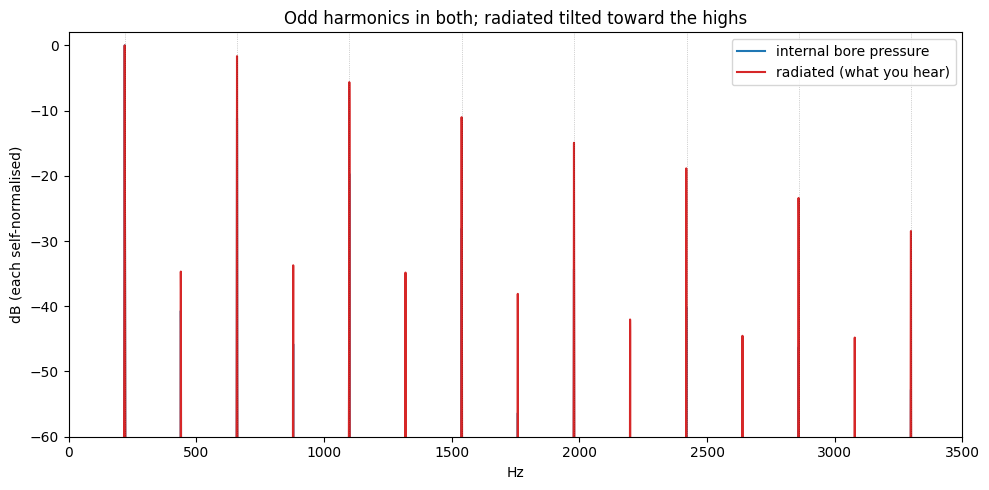

In [46]:
def spectrum_db(sig, sr=SR):
    w = np.hanning(len(sig))
    mag = np.abs(np.fft.rfft(sig*w))
    return np.fft.rfftfreq(len(sig), 1/sr), 20*np.log10(mag/np.max(mag) + 1e-6)
 
seg_i = internal[SR//4:]; seg_r = radiated[SR//4:]
f_i, db_i = spectrum_db(seg_i)
f_r, db_r = spectrum_db(seg_r)
 
plt.figure(figsize=(10, 5))
plt.plot(f_i, db_i, label="internal bore pressure", color="C0")
plt.plot(f_r, db_r, label="radiated (what you hear)", color="C3")
for k in range(1, 16, 2):
    plt.axvline(220*k, color="k", ls=":", lw=0.5, alpha=0.35)
plt.xlim(0, 3500); plt.ylim(-60, 2)
plt.xlabel("Hz"); plt.ylabel("dB (each self-normalised)")
plt.title("Odd harmonics in both; radiated tilted toward the highs")
plt.legend(); plt.tight_layout(); plt.show()

 The opening sets the radiation cutoff

 The single most important lever. The cutoff is fixed by how the wavelength compares
 to the opening (`ka ~ 1`). A small opening (high cutoff) lets only the very top
escape — thin and quiet. A larger opening (lower cutoff) lets progressively lower
 frequencies out — fuller. Watch the radiated centroid drop as the opening grows.

Note the pitch drifts as you change the cutoff: a lower cutoff adds reflection
group delay = more end correction = flatter. Retrim `loop_comp` to re-tune. That
coupling is physical, not a bug.

In [48]:
def centroid(sig, sr=SR):
    w = np.hanning(len(sig)); S = np.abs(np.fft.rfft(sig*w))
    f = np.fft.rfftfreq(len(sig), 1/sr)
    return np.sum(f*S)/np.sum(S)
 
print(f"{'opening radius':>14} {'cutoff Hz':>10} {'radiated centroid':>18}")
for r_mm in [4, 7, 12, 20, 35]:
    fc = cutoff_from_radius(r_mm/1000)
    rad, _ = wind(bore, f0=220, pm=0.5, dur=1.5, rad_cutoff_hz=fc)
    print(f"{r_mm:>11} mm {fc:>10.0f} {centroid(rad[SR//4:]):>16.0f} Hz")

opening radius  cutoff Hz  radiated centroid
          4 mm      13648             2125 Hz
          7 mm       7799             1923 Hz
         12 mm       4549             1614 Hz
         20 mm       2730             1200 Hz
         35 mm       1560              807 Hz
